---

## Python Code: Building Your First Neural Network 🐍

We'll build a neural network to classify handwritten digits (0-9) using the famous **MNIST dataset**.


python
###### ============================================================
 ```
 🧠 YOUR FIRST NEURAL NETWORK WITH KERAS
 Task: Recognize handwritten digits (0-9)
 Dataset: MNIST (70,000 handwritten digit images)
```
###### ============================================================

#### STEP 1: Import Libraries

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

##### ============================================================
#### STEP 2: Load and Explore the Data
##### ============================================================

### MNIST comes built into Keras — how convenient!

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
print("\n📊 Dataset Shape:")
print(f"Training images:   {X_train.shape}")  # (60000, 28, 28)
print(f"Training labels:   {y_train.shape}")  # (60000,)
print(f"Testing images:    {X_test.shape}")   # (10000, 28, 28)
print(f"Testing labels:    {y_test.shape}")   # (10000,)


📊 Dataset Shape:
Training images:   (60000, 28, 28)
Training labels:   (60000,)
Testing images:    (10000, 28, 28)
Testing labels:    (10000,)



###### Each image is 28x28 pixels = 784 numbers
###### Each pixel value is 0 (black) to 255 (white)


#### Let's see what the data looks like!

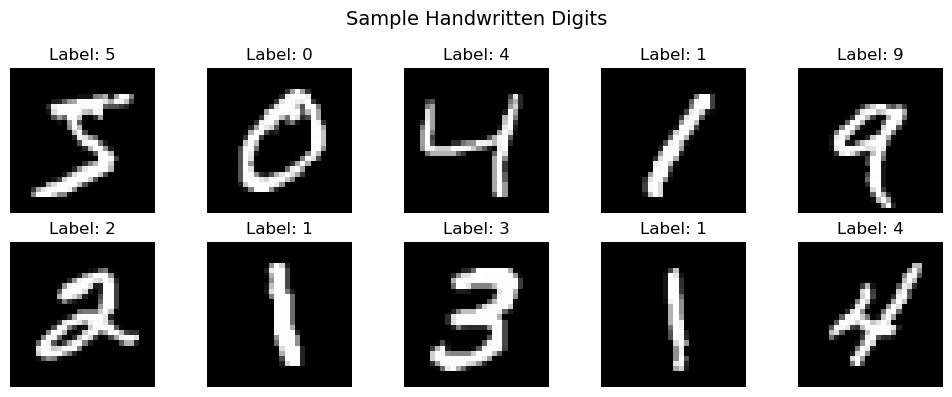

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample Handwritten Digits", fontsize=14)
plt.tight_layout()
plt.show()

##### ============================================================
#### STEP 3: Preprocess the Data
##### ============================================================

```
 3a. FLATTEN: Convert 28x28 grid → 784 numbers in a line
     Why? Our basic neural network expects a 1D input

    28×28 image:           Flattened:
     [pixel, pixel, ...]    [pixel, pixel, pixel, ... 784 total]
     [pixel, pixel, ...]    
     (28 rows × 28 cols)
```

In [ ]:
X_train_flat = X_train.reshape(-1, 784)  # -1 means "figure out this dim"
X_test_flat  = X_test.reshape(-1, 784)

In [ ]:
print(f"\nAfter flattening:")
print(f"Training shape: {X_train_flat.shape}")  # (60000, 784)


After flattening:
Training shape: (60000, 784)


```
 3b. NORMALIZE: Scale pixel values from 0-255 to 0-1
     Why? Smaller numbers = easier and faster for network to learn

     Before: [0, 128, 255, 64, ...]   
     After:  [0.0, 0.50, 1.0, 0.25, ...]  ← all between 0 and 1
```

In [ ]:
X_train_norm = X_train_flat / 255.0
X_test_norm  = X_test_flat  / 255.0

print(f"\nPixel value range before: {X_train_flat.min()} to {X_train_flat.max()}")
print(f"Pixel value range after:  {X_train_norm.min():.1f} to {X_train_norm.max():.1f}")


Pixel value range before: 0 to 255
Pixel value range after:  0.0 to 1.0


##### ============================================================
#### STEP 4: Build the Neural Network
##### ============================================================

#### Our network architecture:
```
INPUT LAYER        HIDDEN LAYER 1     HIDDEN LAYER 2     OUTPUT LAYER
784 neurons      →→→  128 neurons    →→→  64 neurons   →→→  10 neurons
(one per pixel)        (ReLU)             (ReLU)             (Softmax)
                                                   (one per digit 0-9)
```

OLD Code
model = keras.Sequential([
    
    # --- HIDDEN LAYER 1 ---
    # 128 neurons, ReLU activation
    # input_shape tells it our data has 784 features
    layers.Dense(128, activation='relu', input_shape=(784,)),
    # Dense = every neuron connects to every neuron in next layer
    
    # --- DROPOUT LAYER --- (Bonus: Prevents overfitting!)
    # Randomly "turns off" 20% of neurons during training
    # Forces network to not rely on any single neuron
    layers.Dropout(0.2),
    
    # --- HIDDEN LAYER 2 ---
    # 64 neurons, ReLU activation
    layers.Dense(64, activation='relu'),
    
    # --- OUTPUT LAYER ---
    # 10 neurons (one for each digit: 0, 1, 2, ..., 9)
    # Softmax converts raw scores to probabilities (must sum to 1)
    layers.Dense(10, activation='softmax')
    
])

NEW 

In [ ]:
model = keras.Sequential([
    # Input layer (new recommended way)
    keras.Input(shape=(784,)),

    # Hidden Layer 1 — 128 neurons, ReLU
    layers.Dense(128, activation='relu'),

    # Dropout — prevents overfitting
    layers.Dropout(0.2),

    # Hidden Layer 2 — 64 neurons, ReLU
    layers.Dense(64, activation='relu'),

    # Output Layer — 10 classes (digits 0-9)
    layers.Dense(10, activation='softmax')
])

##### Print a summary of your network!

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

##### ============================================================
#### STEP 5: Compile the Model
##### ============================================================


##### Tell the model HOW to learn:

In [ ]:
model.compile(
    optimizer='adam',          # 🎯 How to update weights
                               #    Adam = smart version of gradient descent
    
    loss='sparse_categorical_crossentropy',  
                               # 📉 How to measure error
                               #    Use this for multi-class classification
    
    metrics=['accuracy']       # 📊 What to track during training
)

print("\n✅ Model compiled successfully!")


✅ Model compiled successfully!


##### ============================================================
#### STEP 6: Train the Model!
##### ============================================================

In [ ]:
print("\n🚀 Starting Training...")
print("=" * 50)


🚀 Starting Training...


In [ ]:
history = model.fit(
    X_train_norm,    # Training images
    y_train,         # Training labels (correct answers)
    epochs=10,       # How many times to see ALL training data
                     # (like reading a textbook 10 times)
    batch_size=32,   # Process 32 images at a time before updating weights
    validation_split=0.1,  # Use 10% of training data to monitor progress
    verbose=1        # Show progress bar
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9099 - loss: 0.3034 - val_accuracy: 0.9642 - val_loss: 0.1294
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9562 - loss: 0.1431 - val_accuracy: 0.9745 - val_loss: 0.0850
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9658 - loss: 0.1123 - val_accuracy: 0.9763 - val_loss: 0.0732
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9712 - loss: 0.0926 - val_accuracy: 0.9807 - val_loss: 0.0679
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9752 - loss: 0.0784 - val_accuracy: 0.9767 - val_loss: 0.0838
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9769 - loss: 0.0716 - val_accuracy: 0.9805 - val_loss: 0.0670
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9779 - loss: 0.0658 - val_accuracy: 0.9785 - val_loss: 0.0834
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9808 - loss: 0.0596 - 

### Epochs explained:
```
 Epoch 1: Network sees all 60,000 images once → makes lots of mistakes
 Epoch 5: Network has seen images 5 times → getting better!
 Epoch 10: Network has seen images 10 times → quite good now!
```
##### ============================================================
#### STEP 7: Evaluate the Model
##### ============================================================

In [ ]:
print("\n📊 Evaluating on Test Data (never seen before!)...")
test_loss, test_accuracy = model.evaluate(X_test_norm, y_test, verbose=0)

print(f"\n🎯 Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"📉 Test Loss:     {test_loss:.4f}")



📊 Evaluating on Test Data (never seen before!)...

🎯 Test Accuracy: 0.9779 (97.79%)
📉 Test Loss:     0.0792


##### ============================================================
#### STEP 8: Visualize Training Progress
##### ============================================================

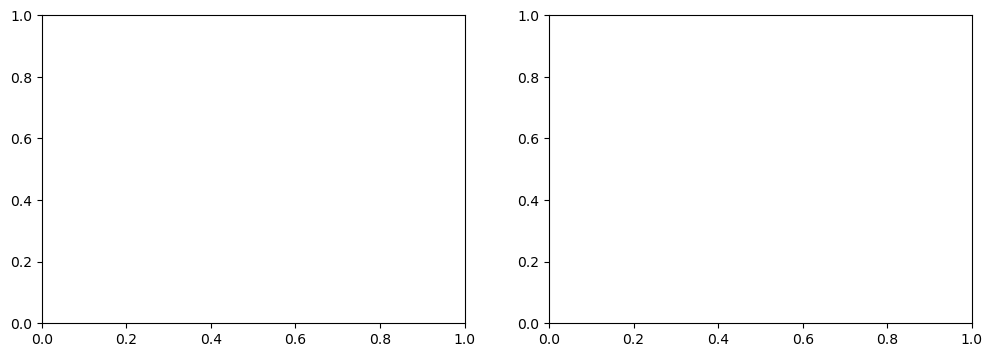

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

##### Plot Accuracy

In [ ]:
ax1.plot(history.history['accuracy'],     label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('Model Accuracy Over Time')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

##### Plot Loss

In [ ]:
ax2.plot(history.history['loss'],     label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('Model Loss Over Time')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

##### ============================================================
#### STEP 9: Make Predictions! 🔮
##### ============================================================


##### Predict on first 5 test images

In [ ]:
predictions = model.predict(X_test_norm[:5])

print("\n🔮 Predictions for first 5 test images:")
print("-" * 40)
for i in range(5):
    predicted_digit = np.argmax(predictions[i])     # digit with highest probability
    actual_digit    = y_test[i]
    confidence      = predictions[i][predicted_digit] * 100
    
    status = "✅" if predicted_digit == actual_digit else "❌"
    print(f"Image {i+1}: Predicted={predicted_digit}, Actual={actual_digit}, "
          f"Confidence={confidence:.1f}% {status}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

🔮 Predictions for first 5 test images:
----------------------------------------
Image 1: Predicted=7, Actual=7, Confidence=100.0% ✅
Image 2: Predicted=2, Actual=2, Confidence=99.6% ✅
Image 3: Predicted=1, Actual=1, Confidence=100.0% ✅
Image 4: Predicted=0, Actual=0, Confidence=100.0% ✅
Image 5: Predicted=4, Actual=4, Confidence=100.0% ✅


##### ============================================================
#### STEP 10: Visualize Predictions
##### ============================================================

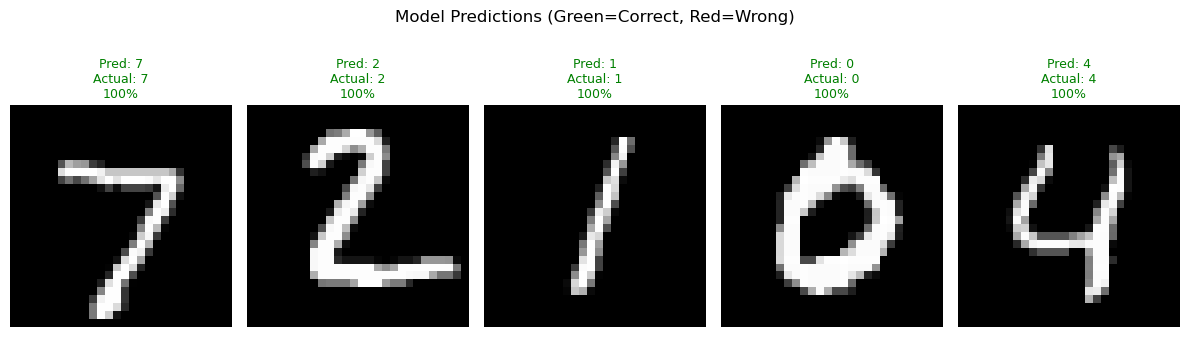

In [ ]:
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i], cmap='gray')
    
    predicted = np.argmax(predictions[i])
    actual    = y_test[i]
    confidence = predictions[i][predicted] * 100
    
    color = 'green' if predicted == actual else 'red'
    plt.title(f"Pred: {predicted}\nActual: {actual}\n{confidence:.0f}%", 
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle("Model Predictions (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout()
plt.show()

### Expected Output:

TensorFlow version: 2.x.x

```
📊 Dataset Shape:
Training images:   (60000, 28, 28)
Training labels:   (60000,)
Testing images:    (10000, 28, 28)
Testing labels:    (10000,)

Model: "sequential"
_________________________________________________________________
Layer (type)             Output Shape          Param #   
=================================================================
dense (Dense)            (None, 128)           100,480   
dropout (Dropout)        (None, 128)           0         
dense_1 (Dense)          (None, 64)            8,256     
dense_2 (Dense)          (None, 10)            650       
=================================================================
Total params: 109,386
Trainable params: 109,386
_________________________________________________________________

🚀 Starting Training...
Epoch 1/10:  loss: 0.3821 - accuracy: 0.8911
Epoch 5/10:  loss: 0.1124 - accuracy: 0.9659
Epoch 10/10: loss: 0.0712 - accuracy: 0.9789

🎯 Test Accuracy: 0.9756 (97.56%)

🔮 Predictions for first 5 test images:
----------------------------------------
Image 1: Predicted=7, Actual=7, Confidence=99.9% ✅
Image 2: Predicted=2, Actual=2, Confidence=99.7% ✅
Image 3: Predicted=1, Actual=1, Confidence=99.8% ✅
Image 4: Predicted=0, Actual=0, Confidence=99.5% ✅
Image 5: Predicted=4, Actual=4, Confidence=98.2% ✅
```

---

## 🗺️ Your Learning Roadmap

```
You are           NEXT STEPS:
here! 📍
   │
   ▼
[Neural Networks Basics] ──→ [CNNs for Images 🖼️]
                         ──→ [RNNs for Text/Time Series 📝]
                         ──→ [Transfer Learning 🚀]
                         ──→ [Building Real Projects 🛠️]
```

## 🎯 Quick Reference Cheatsheet

```
┌─────────────────────────────────────────────────────────────┐
│                    NEURAL NETWORKS 101                      │
├─────────────────┬───────────────────────────────────────────┤
│ Neuron          │ Basic unit that receives, processes,      │
│                 │ and passes on information                 │
├─────────────────┼───────────────────────────────────────────┤
│ Weight          │ Importance of each connection             │
├─────────────────┼───────────────────────────────────────────┤
│ Forward Pass    │ Data flows input → output (making guess)  │
├─────────────────┼───────────────────────────────────────────┤
│ Loss            │ How wrong was the guess?                  │
├─────────────────┼───────────────────────────────────────────┤
│ Backpropagation │ Update weights based on the mistake       │
├─────────────────┼───────────────────────────────────────────┤
│ ReLU            │ Best for hidden layers                    │
├─────────────────┼───────────────────────────────────────────┤
│ Sigmoid         │ Best for binary output (yes/no)           │
├─────────────────┼───────────────────────────────────────────┤
│ Softmax         │ Best for multi-class output               │
├─────────────────┼───────────────────────────────────────────┤
│ Epoch           │ One full pass through ALL training data   │
├─────────────────┼───────────────────────────────────────────┤
│ Batch Size      │ How many samples processed at once        │
└─────────────────┴───────────────────────────────────────────┘
```

**You just learned the fundamentals of Neural Networks and Deep Learning! 🎉 Keep practicing and building projects — that's the fastest way to truly master this!**